This notebook requires that the constraint and the numb_sites_region are run before

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [32]:
Constraint = pd.read_csv("Output_data/Constraint_perregion.csv")
numb_sites = pd.read_csv("Output_data/number_sites_perregion.csv")
Sum_NumbSties_PropMut = pd.read_csv("Output_data/Sum_NumbSties_PropMut.csv")
with open("Output_data/constantofmu.txt", "r") as f:
    mu_constant = float(f.read().strip())

In [33]:
Constraint = Constraint[Constraint["Sequence type"] != "IG"]
Constraint

,Sequence type,Constraint
0,cds,0.451172
1,introns,0.249704
2,3UTR,0.275495
3,5UTR,0.308225
4,intronsAR,0.138393
5,distalIG,0.039331
6,proximal5IG,0.115664
7,proximal3IG,0.134434


In [34]:
numb_sites = numb_sites[numb_sites["Sequence type"] != "IGAR"]
numb_sites

,Sequence type,Haploid sequence length
0,cds,543237
1,introns,6684962
2,3UTR,100622
3,5UTR,106413
4,intronsAR,5463116
5,distalIG,1079639
6,proximal5IG,539644
7,proximal3IG,539839


In [35]:
Sum_NumbSties_PropMut

,Sequence type,Sum NumbSites PropMut
0,cds,4.605976e+05
1,introns,3.954867e+06
2,3UTR,7.273164e+04
3,5UTR,7.507344e+04
4,intronsAR,3.234076e+06
5,distalIG,6.385270e+05
6,proximal5IG,3.334168e+05
7,proximal3IG,3.366822e+05


In [36]:
mu_constant

2.229275376454005e-08

In [37]:
sum(numb_sites["Haploid sequence length"])

15057472

Check visually that the two tables above have the same order of rows.

In [38]:
Udregion = mu_constant*(Constraint["Constraint"] * 2 * (Sum_NumbSties_PropMut["Sum NumbSites PropMut"]))
Udregion

0    0.009265
1    0.044030
2    0.000893
3    0.001032
4    0.019955
5    0.001120
6    0.001719
7    0.002018
dtype: float64

In [39]:
UdChrom22 = sum(Udregion)
UdChrom22

0.08003304794118515

Text(0, 0.5, '% of total Ud')

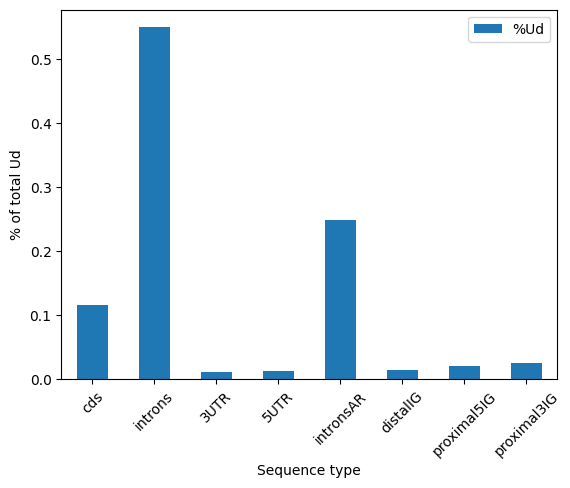

In [49]:
Uddata = pd.DataFrame({
    'Sequence type':  Constraint["Sequence type"],
    '%Ud': Udregion/UdChrom22
})
Uddata.plot(
    x='Sequence type',
    kind = 'bar',
    rot=45)
plt.ylabel('% of total Ud')

In [46]:
Chrom22sites = 51*10**6
totalsites = 3.1*10**9
# How many times I got to multiply chromosome 22 to get a whole genome estimate
howmanytimesChrom22 = totalsites/Chrom22sites
howmanytimesChrom22

Ud = UdChrom22*howmanytimesChrom22
Ud

4.8647538944641955